## Graphing

### To Run:
- use conda / environment manager to set up a python3 kernel
- select kernel in top right 
- press 'run all'

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [2]:
# 1. get .csv files
file_names = os.listdir(".")
file_names.remove("graphs.ipynb")
print(file_names)

['A100-level1-float64.csv', 'H100-level1-float32.csv', 'MI300-level1-float64.csv', 'A100-level1-float32.csv', 'H100-level1-float64.csv', 'MI300-level1-float32.csv']


In [3]:
# 2. read each csv file, store data (using pandas dataframes)
df = pd.DataFrame()
for csv in file_names:
    df_csv = pd.read_csv(csv)
    df = pd.concat([df, df_csv], axis=0)

In [4]:
# 3. filter
df_filtered = df[df['device'] != 'cpu']
df_filtered = df_filtered[df_filtered['device'] != 'NVIDIA H100 NVL']

In [5]:
# 4. create groupings (operation, dtype) for graphing and store in dictionary
op_dict = {
    dtype: {op: grp for op, grp in dtype_grp.groupby('op')}
    for dtype, dtype_grp in df_filtered.groupby('dtype')
}

In [6]:
# 4. plot (each op for each machine)
num_rows = 3
num_columns = 4
y_values = ['bandwidth_GBs', 'avg_ns']

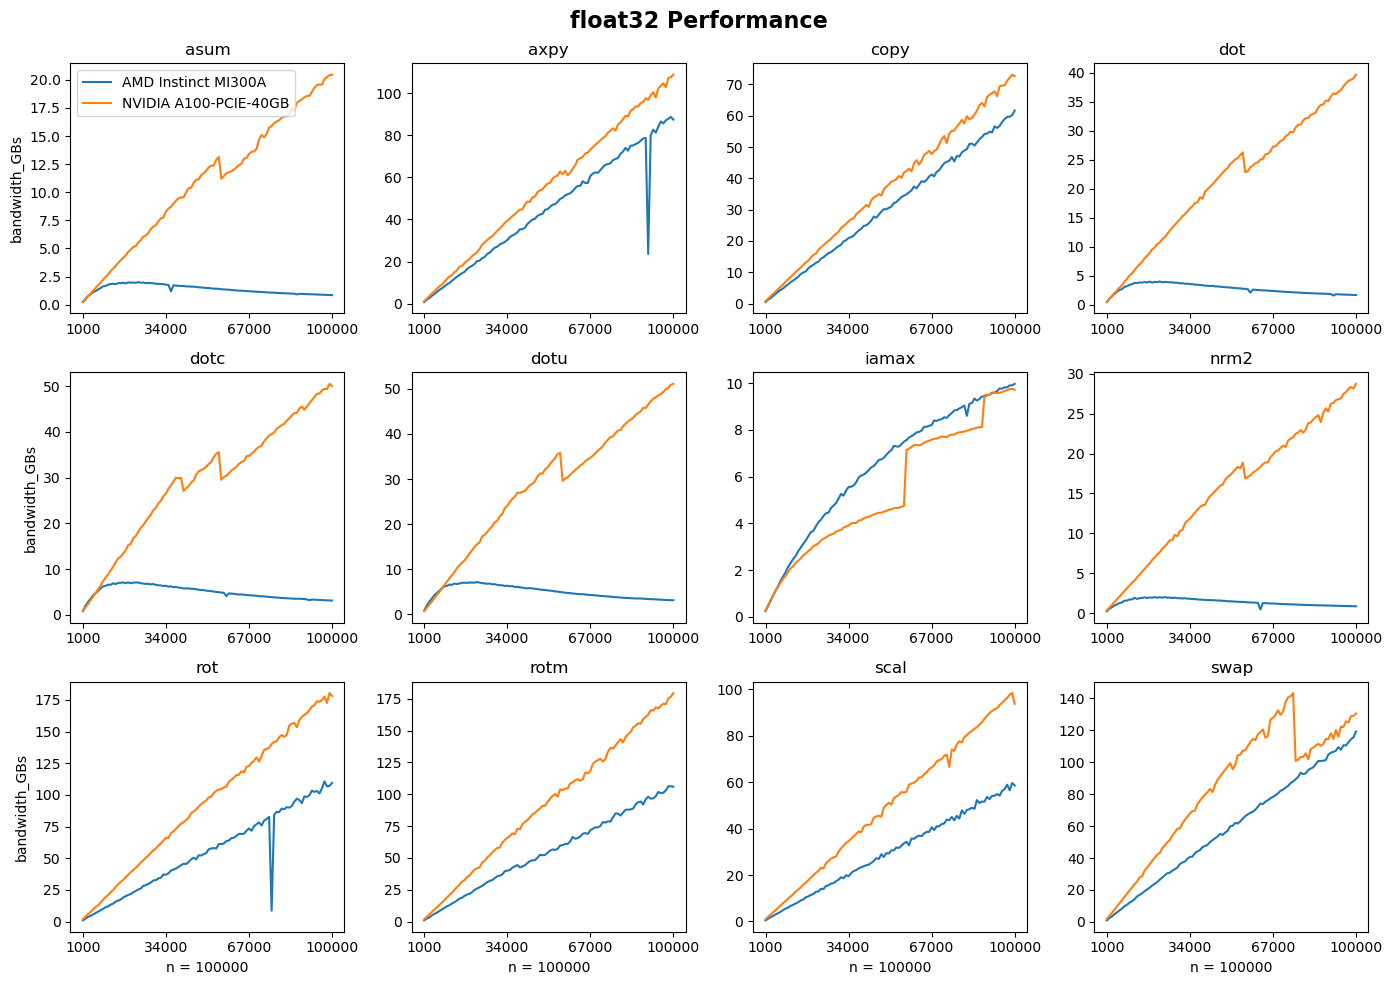

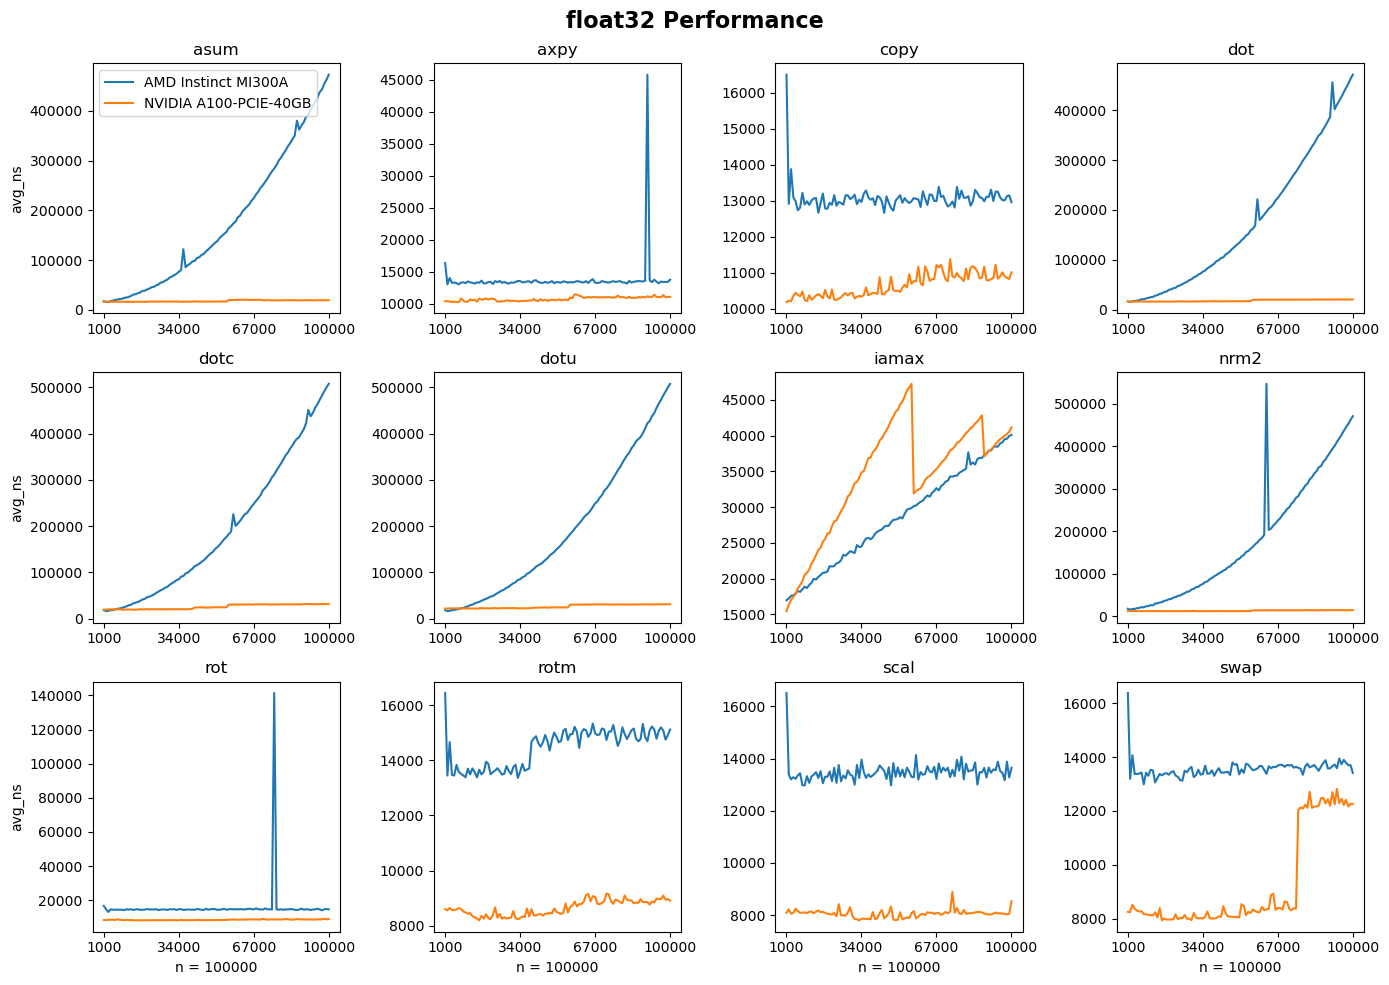

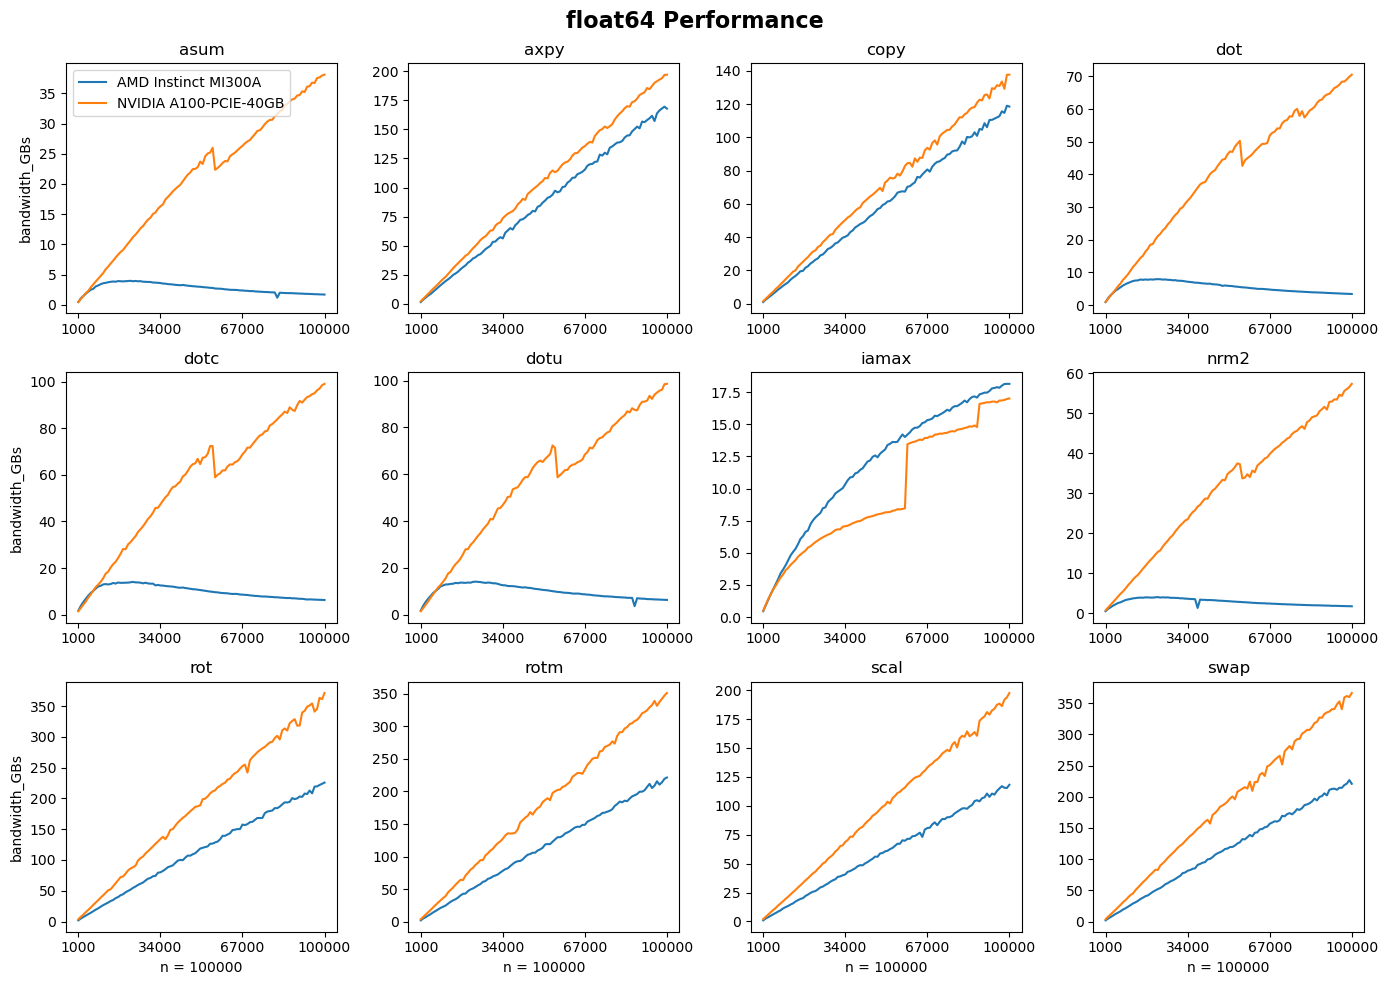

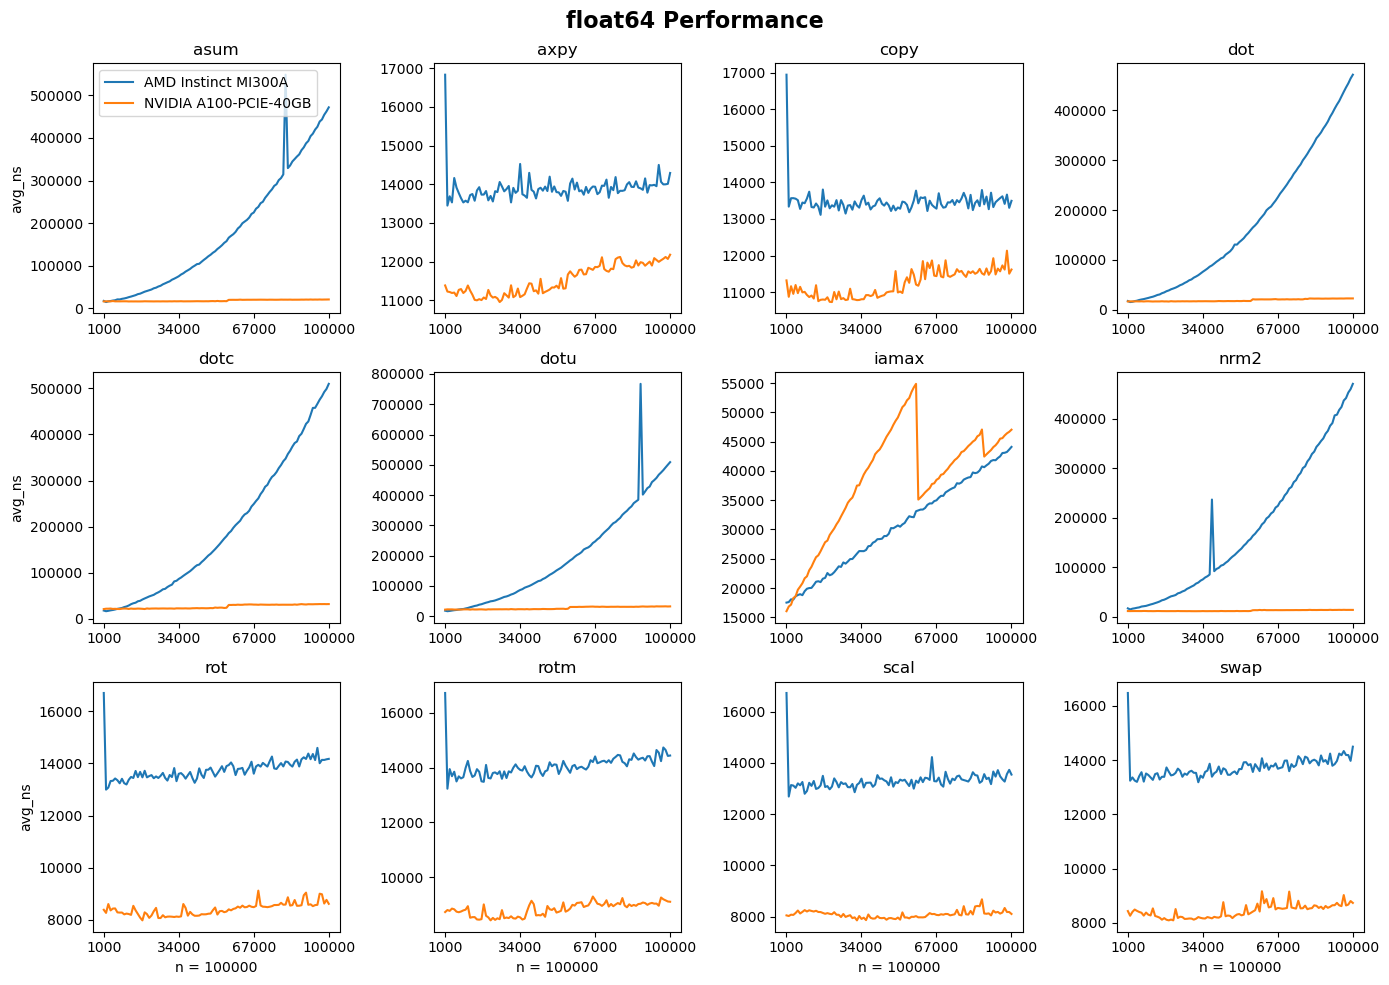

In [9]:
def plot_device_group(ax, device_df_dict, key, y_val, num_ticks=10):
    """Plot all devices for a single operation on one axis. This generates each subfigure."""
    for label, device_df in device_df_dict.items():
        x = pd.to_numeric(device_df.n, errors='coerce')
        y = pd.to_numeric(device_df[y_val], errors='coerce')
        ax.plot(x, y, label=label)

    ax.set_title(key)
    ax.set_xticks(np.linspace(x.min(), x.max(), num=num_ticks))
    return x  # return for axis labeling


def plot_performance(data_dict, y_val, num_rows=3, num_columns=4):
    """Plot each operation across devices for a given y variable. This generates each figure."""
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_columns, figsize=(14, 10))

    for i, (key, value) in enumerate(data_dict.items()):
        row, col = divmod(i, num_columns)
        ax = axes[row, col]

        device_df_dict = {name: grp for name, grp in value.groupby('device')}
        x = plot_device_group(ax, device_df_dict, key, y_val, 4)

        if col == 0:
            ax.set_ylabel(y_val)
        if row == num_rows - 1:
            ax.set_xlabel(f'n = {x.max()}')
        if col == 0 and row == 0:
            ax.legend()

    dtype_label = value.dtype.to_list()[0]
    fig.suptitle(f'{dtype_label} Performance', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# -- main loop --
for data_dict in op_dict.values():
    for y_val in y_values:
        plot_performance(data_dict, y_val, num_rows, num_columns)